# Candidate Test 2022 Analysis Part 1

This exercise focuses on the candidate tests from two television networks: DR and TV2. Data from both tests have been given on a scale of five responses (-2, -1, 0, 1, 2).

---

There are 6 datasets included in this exercise:

- `alldata.xlsx`: Contains responses from both TV stations.
- `drdata.xlsx`: Contains responses from DR.
- `drq.xlsx`: Contains questions from DR.
- `tv2data.xlsx`: Contains responses from TV2.
- `tv2q.xlsx`: Contains questions from TV2.
- `electeddata.xlsx`: Contains responses from both TV stations for candidates who were elected to the parliament. Note that 9 members are missing; 7 of them didn't take any of the tests. Additionally, some notable figures like Mette F. and Lars Løkke did not participate in any of the tests.

---

It's entirely up to you how you approach this data, but at a *minimum*, your analysis should include:
- Age of the candidates grouped by parties.
- An overview of the most "confident" candidates, i.e., those with the highest proportion of "strongly agree" or "strongly disagree" responses.
- Differences in responses between candidates, both inter-party and intra-party, along with an explanation of which parties have the most internal disagreements.
- Classification models to predict candidates' party affiliations. Investigate if there are any candidates who seem to be in the "wrong" party based on their political landscape positions. You must use the following  algorithms: **Decision Tree**, **Random Forest** and **Gradient Boosted Tree**, i.e. a total of 3 models are to be trained.

---

The following parties are represented:

| Party letter | Party name | Party name (English) | Political position |
| :-: | :-: | :-: | :-: |
| A | Socialdemokratiet | Social Democrats | Centre-left |
| V | Venstre | Danish Liberal Party | Centre-right |
| M | Moderaterne | Moderates | Centre-right |
| F | Socialistisk Folkeparti | Socialist People's Party | Left-wing |
| D | Danmarksdemokraterne | Denmark Democrats | Right-wing |
| I | Liberal Alliance | Liberal Alliance | Right-wing |
| C | Konservative | Conservative People's Party | Right-wing |
| Æ | Enhedslisten | Red-Green Alliance | Far-left |
| B | Radikale Venstre | Social Liberal Party | Centre-left |
| D | Nye Borgerlige | New Right | Far-right |
| Z | Alternativet | The Alternative | Centre-left |
| O | Dansk Folkeparti | Danish People's Party | Far-right |
| G | Frie Grønne | Free Greens | Centre-left |
| K | Kristendemokraterne | Christian Democrats | Centre-right |

Below you can see the results and the colors chosen to represent the parties. Use these colors in your analysis above.

![Alt text](image-1.png)


Others have undertaken similar analyses. You can draw inspiration from the following (use Google tranlsate if your Danish is rusty):

- [Analysis of where individual candidates stand relative to each other and their parties](https://v2022.dumdata.dk/)
- [Candidate Test 2022 – A deep dive into the data](https://kwedel.github.io/kandidattest2022/)
- [The Political Landscape 2019](https://kwedel.github.io/kandidattest2019/)



# What the raw tables tell us
- `alldata.xlsx` columns tell us about as follows:
    - numbered columns (530-563) refer to the ID of the question of the `drq.xlsx`
    - number with alphabet: id of the questions which can be found on the `tv2q.xlsx`
    - candidate infos
      *  name
      *  party
      *  age (at 2022)
      *  responsible on which region
  

In [223]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import plot_tree

Task01: check outliers (age)

In [224]:
raw_all_data = pd.read_excel("alldata.xlsx")
raw_all_data.head()


,530,531,533,534,535,537,538,540,541,543,...,9a,9b,10a,10b,11a,11b,12a,12b,storkreds,alder
0,-1,-2,1,-2,2,1,-2,1,1,2,...,2,0,1,-2,-2,1,1,1,Københavns Storkreds,78
1,2,2,-1,-2,-1,-2,1,-2,2,-2,...,-2,0,-1,2,1,-2,0,0,Fyns Storkreds,64
2,2,1,-2,-2,1,-2,1,-1,1,-1,...,-1,-2,0,2,0,-1,1,-2,Bornholms Storkreds,37
3,2,1,-2,-1,1,1,1,1,1,-2,...,-2,2,2,2,2,-1,2,0,Nordjyllands Storkreds,28
4,1,1,-2,2,-2,1,-2,1,2,-2,...,-2,0,-1,0,-2,0,2,-2,Københavns Storkreds,58


In [225]:
raw_all_data.isnull().sum()

530          0
531          0
533          0
534          0
535          0
537          0
538          0
540          0
541          0
543          0
544          0
545          0
546          0
547          0
548          0
550          0
551          0
552          0
553          0
555          0
556          0
557          0
559          0
561          0
563          0
navn         0
parti        0
1a           0
1b           0
2a           0
2b           0
3a           0
3b           0
4a           0
4b           0
5a           0
5b           0
6a           0
6b           0
7a           0
7b           0
8a           0
8b           0
9a           0
9b           0
10a          0
10b          0
11a          0
11b          0
12a          0
12b          0
storkreds    0
alder        0
dtype: int64

In [226]:
missing_percent = raw_all_data.isnull().mean() * 100
print(missing_percent)

530          0.0
531          0.0
533          0.0
534          0.0
535          0.0
537          0.0
538          0.0
540          0.0
541          0.0
543          0.0
544          0.0
545          0.0
546          0.0
547          0.0
548          0.0
550          0.0
551          0.0
552          0.0
553          0.0
555          0.0
556          0.0
557          0.0
559          0.0
561          0.0
563          0.0
navn         0.0
parti        0.0
1a           0.0
1b           0.0
2a           0.0
2b           0.0
3a           0.0
3b           0.0
4a           0.0
4b           0.0
5a           0.0
5b           0.0
6a           0.0
6b           0.0
7a           0.0
7b           0.0
8a           0.0
8b           0.0
9a           0.0
9b           0.0
10a          0.0
10b          0.0
11a          0.0
11b          0.0
12a          0.0
12b          0.0
storkreds    0.0
alder        0.0
dtype: float64


Text(0.5, 1.0, 'Age')

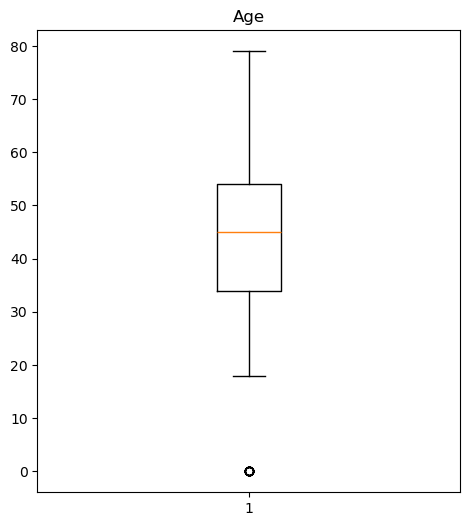

In [227]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.boxplot(raw_all_data['alder'].dropna())
plt.title('Age')

let's get rid of outlier (age $=0$ doesn't make sense)

Text(0.5, 1.0, 'Age')

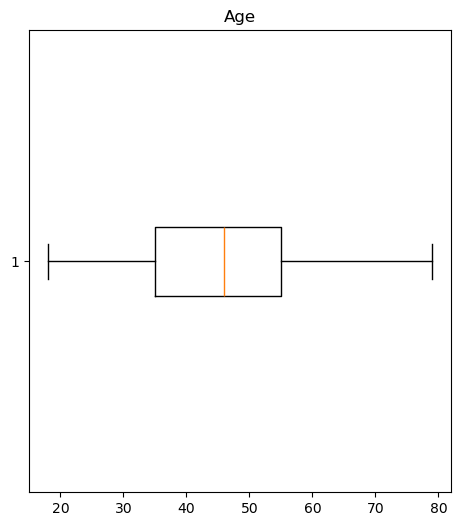

In [228]:
Q1 = raw_all_data['alder'].quantile(0.25)
Q3 = raw_all_data['alder'].quantile(0.75)

IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR # no need upper bound cuz outliers are only on the lower end
raw_all_data_filtered = raw_all_data[(raw_all_data['alder'] >= lower_bound)]

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.boxplot(raw_all_data_filtered['alder'].dropna(), vert=False)
plt.title('Age')

It's a bit left skewed, not that much, no apply function needed, but we can applying the plot with increase derivative function like $x^2$ if needed for bell curve function

In [229]:
average_age_by_party = raw_all_data_filtered.groupby('parti')['alder'].mean()

# If you want to sort the results to make it easier to read:
average_age_by_party = average_age_by_party.sort_values()

print(average_age_by_party)

parti
Frie Grønne, Danmarks Nye Venstrefløjsparti    34.807692
Liberal Alliance                               37.970588
Socialistisk Folkeparti                        41.521739
Enhedslisten                                   42.225352
Moderaterne                                    44.261905
Det Konservative Folkeparti                    44.723404
Radikale Venstre                               44.955224
Socialdemokratiet                              45.388235
Dansk Folkeparti                               45.530612
Venstre                                        46.678571
Alternativet                                   47.415385
Løsgænger                                      48.000000
Nye Borgerlige                                 48.520000
Kristendemokraterne                            50.219512
Danmarksdemokraterne                           51.216216
Name: alder, dtype: float64


Task02: find the most confident candidate
- value of -2 and +2 in numbered and alphabetnumbered column

In [230]:
# 1. Identify which columns contain the answers (question columns)
# Here we just drop the metadata columns like 'navn', 'parti', 'alder', etc.
metadata_cols = ['navn', 'parti', 'alder', 'storkreds']
question_cols = [col for col 
                 in raw_all_data_filtered.columns 
                 if col not in metadata_cols]

# 2. Check if the value is either -2 or 2 in all those columns
# .isin() returns a boolean True/False dataframe
is_confident = raw_all_data_filtered[question_cols].isin([-2, 2])

raw_all_data_filtered['confident_answers_sum'] = is_confident.sum(axis=1)

# 3. View the result sorted by the most confident candidates (both strongly agreeing and strongly disagreeing)
most_confident = raw_all_data_filtered[['navn', 'parti', 'confident_answers_sum']].sort_values(by='confident_answers_sum', ascending=False)
most_confident.head(10)

C:\Users\konkd\AppData\Local\Temp\ipykernel_6668\1493754156.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_all_data_filtered['confident_answers_sum'] = is_confident.sum(axis=1)


,navn,parti,confident_answers_sum
88,Søren Vanting,Det Konservative Folkeparti,49
505,Sarah Nørris,Enhedslisten,49
559,Kim Andkjær Doberck,Nye Borgerlige,44
152,Rashid Ali,"Frie Grønne, Danmarks Nye Venstrefløjsparti",43
44,Mohamed Abdikarim,"Frie Grønne, Danmarks Nye Venstrefløjsparti",43
151,Elise Bjerkrheim,"Frie Grønne, Danmarks Nye Venstrefløjsparti",42
284,John Bjerg,Nye Borgerlige,42
359,Frank Sørensen,Dansk Folkeparti,42
503,Jan Filbært,Enhedslisten,42
437,Lone Vase Langballe,Dansk Folkeparti,42


Task03: measures the disagreement
- can be done by checking the variance
  - if it's low then it's "agreeing"
  - else "disagree"

In [231]:
# Group by party and calculate variance for all question columns
party_variance = raw_all_data_filtered.groupby('parti')[question_cols].var()

# Sum the variances across all questions to get a total disagreement score
total_disagreement = party_variance.sum(axis=1).sort_values(ascending=False)

print("Parties ranked by internal disagreement (highest to lowest):")
print(total_disagreement)

Parties ranked by internal disagreement (highest to lowest):
parti
Løsgænger                                      129.000000
Kristendemokraterne                             54.154878
Alternativet                                    44.525481
Det Konservative Folkeparti                     42.856326
Dansk Folkeparti                                42.531463
Moderaterne                                     41.904762
Radikale Venstre                                39.376300
Venstre                                         36.756598
Socialdemokratiet                               35.581232
Frie Grønne, Danmarks Nye Venstrefløjsparti     31.863077
Liberal Alliance                                31.704785
Enhedslisten                                    27.890946
Socialistisk Folkeparti                         24.130861
Danmarksdemokraterne                            20.447447
Nye Borgerlige                                  19.948980
dtype: float64


In [232]:
# Calculate the average answer for each party per question
variance_means = raw_all_data_filtered.groupby('parti')[question_cols].mean().var().sort_values(ascending=False)

print("Most polarizing questions between parties:")
print(variance_means.head())

Most polarizing questions between parties:
555    2.339205
3b     2.278430
6a     2.177149
531    2.138076
6b     2.136073
dtype: float64


Task04 check if there's candidate who seem to in the wrong party
- $y$ (target column) : parties
- $X$ (featurs columns): questions

In [233]:
deleting_cols = ['navn', 'parti', 'alder', 'storkreds']

X = raw_all_data.drop(columns=deleting_cols)
# Convert all column names to strings, cuz some of them are integers and that causes problems with the decision tree later on
X.columns = X.columns.astype(str)
y = raw_all_data["parti"]
X.head()

,530,531,533,534,535,537,538,540,541,543,...,8a,8b,9a,9b,10a,10b,11a,11b,12a,12b
0,-1,-2,1,-2,2,1,-2,1,1,2,...,1,0,2,0,1,-2,-2,1,1,1
1,2,2,-1,-2,-1,-2,1,-2,2,-2,...,0,0,-2,0,-1,2,1,-2,0,0
2,2,1,-2,-2,1,-2,1,-1,1,-1,...,1,1,-1,-2,0,2,0,-1,1,-2
3,2,1,-2,-1,1,1,1,1,1,-2,...,2,2,-2,2,2,2,2,-1,2,0
4,1,1,-2,2,-2,1,-2,1,2,-2,...,1,0,-2,0,-1,0,-2,0,2,-2


In [234]:
y.head()

0                Moderaterne
1    Socialistisk Folkeparti
2               Alternativet
3               Alternativet
4                  Løsgænger
Name: parti, dtype: object

In [235]:
y.isnull().sum()

np.int64(0)

In [236]:
# split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Decision tree model

In [237]:
# train a decision tree classifier
tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [238]:
# evaluate the model on the train set
train_accuracy = tree_clf.score(X_train, y_train)
print(f"Train set accuracy: {train_accuracy:.2f}")

# evaluate the model on the test set
accuracy = tree_clf.score(X_test, y_test)
print(f"Test set accuracy: {accuracy:.2f}")

Train set accuracy: 1.00
Test set accuracy: 0.76


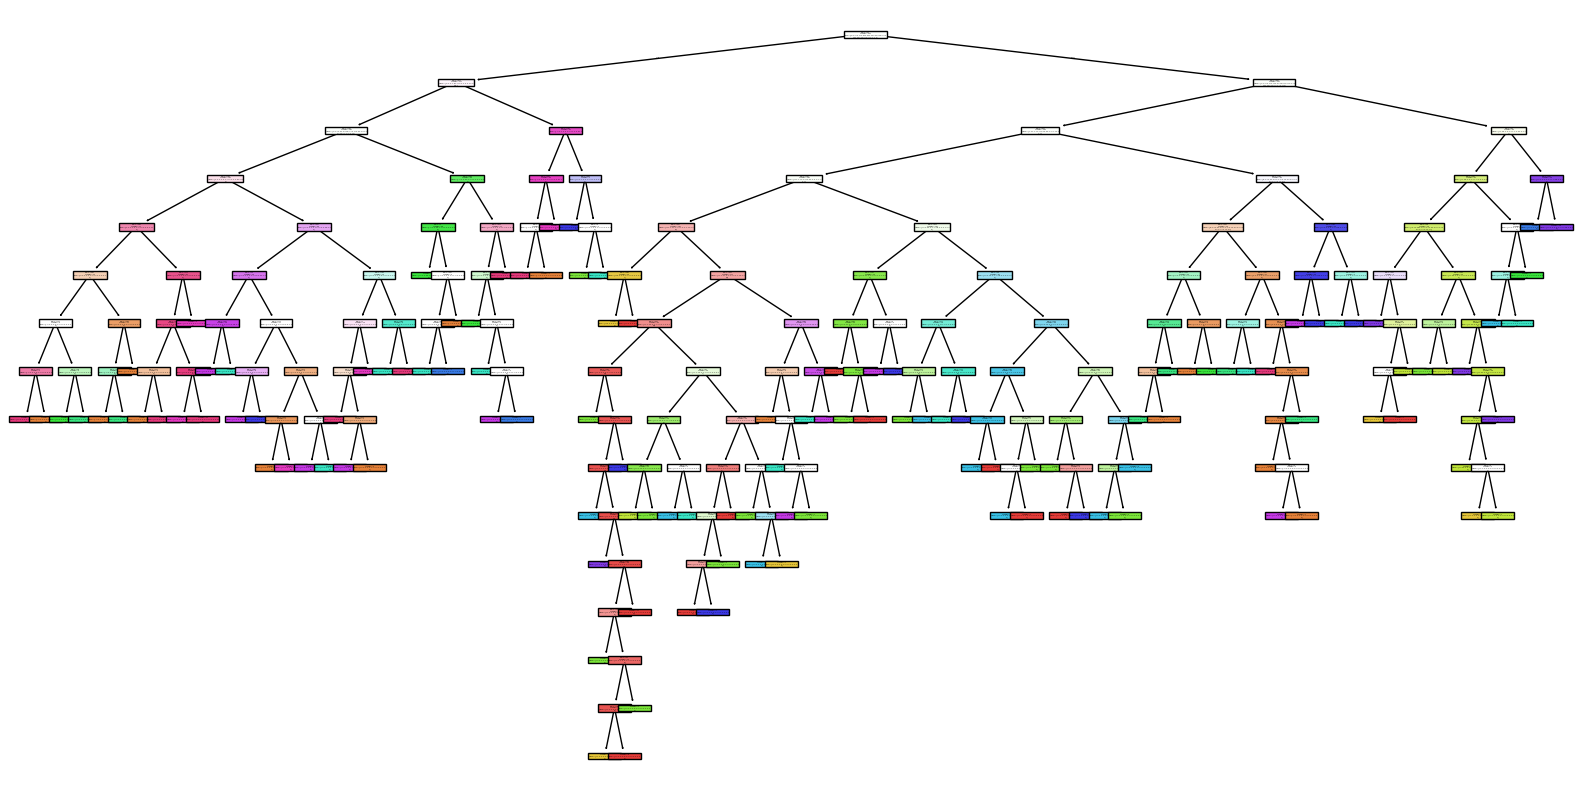

In [239]:
# visualize the decision tree
plt.figure(figsize=(20, 10))
plot_tree(tree_clf, filled=True, feature_names=X.columns)
plt.show()

diabolically huge tree, let's fix it

In [240]:
# set hyperparameters to control the complexity of the tree
tree_clf_pruned = DecisionTreeClassifier(max_depth=6, min_samples_split=7, random_state=42)
tree_clf_pruned.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,6
,min_samples_split,7
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


Train set accuracy of pruned tree: 0.83
Test set accuracy of pruned tree: 0.75


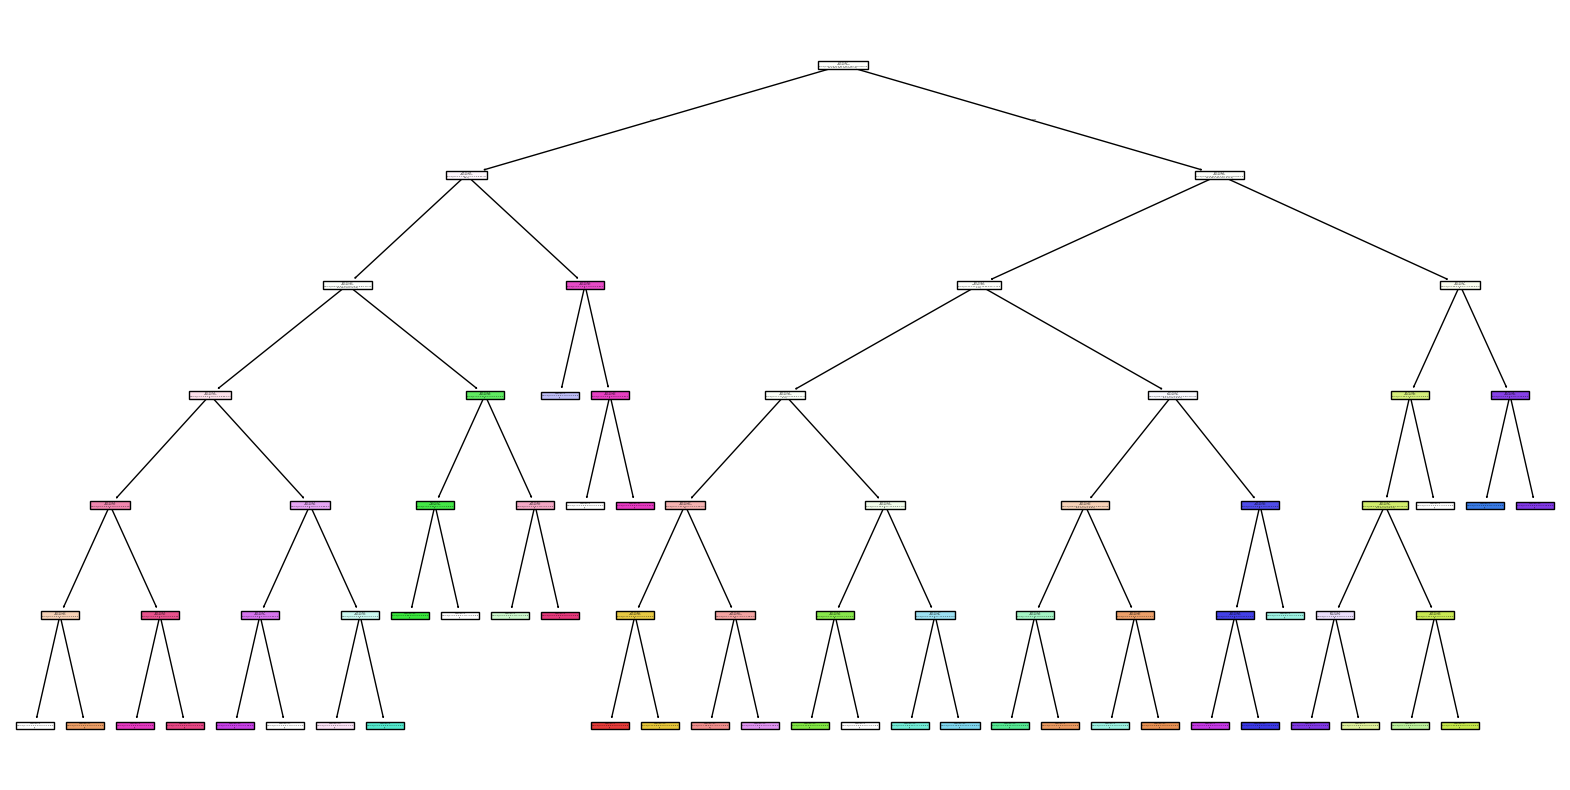

In [241]:
train_accuracy_pruned = tree_clf_pruned.score(X_train, y_train)
print(f"Train set accuracy of pruned tree: {train_accuracy_pruned:.2f}")
accuracy_pruned = tree_clf_pruned.score(X_test, y_test)
print(f"Test set accuracy of pruned tree: {accuracy_pruned:.2f}")
# visualize the decision tree
plt.figure(figsize=(20, 10))
plot_tree(tree_clf_pruned, filled=True, feature_names=X.columns)
plt.show()

In [242]:
all_predictions = tree_clf_pruned.predict(X)

results_df = pd.DataFrame({
    'Name': raw_all_data['navn'],
    'Actual_Party': raw_all_data['parti'],
    'Predicted_Party': all_predictions
})

wrong_party_candidates = results_df[results_df['Actual_Party'] != results_df['Predicted_Party']]

print(f"Found {len(wrong_party_candidates)} candidates who might be in the 'wrong' party:")
wrong_party_candidates.head(20)

Found 160 candidates who might be in the 'wrong' party:


,Name,Actual_Party,Predicted_Party
0,Lars Philipsen Prahm,Moderaterne,Liberal Alliance
1,Karsten Hønge,Socialistisk Folkeparti,Enhedslisten
2,Martin Kelleher-Petersen,Alternativet,Socialistisk Folkeparti
4,Tom Gillesberg,Løsgænger,Alternativet
8,Chresten H. Ibsen,Løsgænger,Enhedslisten
37,Gustav Juul,Venstre,Liberal Alliance
43,Sara Hvidbak Grouleff,"Frie Grønne, Danmarks Nye Venstrefløjsparti",Alternativet
59,Kristian Søndergaard Larsen,Kristendemokraterne,Moderaterne
60,Hanna-Maria Smed Molte Lyng,Kristendemokraterne,Enhedslisten
63,Kurt Vind Christiansen,Liberal Alliance,Venstre


# Random Forest

In [243]:
# train a random forest classifier
n_features = X_train.shape[1]

rf_clf = RandomForestClassifier(n_estimators=100, max_depth=4, random_state=42, max_features=int(np.sqrt(n_features)))
rf_clf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,7
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [244]:
# evaluate the random forest on the train set
train_accuracy_rf = rf_clf.score(X_train, y_train)
print(f"Train set accuracy of random forest: {train_accuracy_rf:.2f}")
# evaluate the random forest on the test set
accuracy_rf = rf_clf.score(X_test, y_test)
print(f"Test set accuracy of random forest: {accuracy_rf:.2f}")

Train set accuracy of random forest: 0.89
Test set accuracy of random forest: 0.89


In [245]:
# feature importance from the random forest
feature_importances = rf_clf.feature_importances_
feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": feature_importances
}).sort_values(by="Importance", ascending=False)
print(feature_importance_df)

   Feature  Importance
3      534    0.069766
20     556    0.057351
46     11b    0.055782
1      531    0.052296
13     547    0.050924
7      540    0.047618
4      535    0.047323
35      6a    0.046861
44     10b    0.042579
36      6b    0.041863
45     11a    0.038837
19     555    0.038479
30      3b    0.031842
5      537    0.030525
16     551    0.025711
6      538    0.022173
12     546    0.020419
29      3a    0.020349
15     550    0.019125
31      4a    0.018245
37      7a    0.017389
11     545    0.016241
22     559    0.014692
9      543    0.014634
10     544    0.013097
2      533    0.013019
14     548    0.012293
28      2b    0.011020
0      530    0.010801
23     561    0.010767
27      2a    0.009040
40      8b    0.007177
26      1b    0.006830
25      1a    0.006825
21     557    0.006579
24     563    0.006345
18     553    0.005702
41      9a    0.005690
48     12b    0.005197
47     12a    0.004724
43     10a    0.004714
39      8a    0.004389
34      5b 

seem like the question is not the 

In [246]:
# Predict the party for all candidates using the Random Forest model
all_predictions = rf_clf.predict(X)

results_df = pd.DataFrame({
    'Name': raw_all_data['navn'],
    'Actual_Party': raw_all_data['parti'],
    'Predicted_Party': all_predictions
})

wrong_party_candidates = results_df[results_df['Actual_Party'] != results_df['Predicted_Party']]

print(f"Found {len(wrong_party_candidates)} candidates who might be in the 'wrong' party:")
wrong_party_candidates.head(20)

Found 94 candidates who might be in the 'wrong' party:


,Name,Actual_Party,Predicted_Party
0,Lars Philipsen Prahm,Moderaterne,Det Konservative Folkeparti
2,Martin Kelleher-Petersen,Alternativet,Socialistisk Folkeparti
3,Nicklas Gjedsig Larsen,Alternativet,Socialdemokratiet
4,Tom Gillesberg,Løsgænger,Alternativet
8,Chresten H. Ibsen,Løsgænger,Radikale Venstre
9,Vinni Kjærgaard Jørgensen,Alternativet,Socialistisk Folkeparti
26,Linda Englyst,Danmarksdemokraterne,Venstre
37,Gustav Juul,Venstre,Det Konservative Folkeparti
39,Stephan Arnold,Venstre,Det Konservative Folkeparti
42,Ali Khatib,"Frie Grønne, Danmarks Nye Venstrefløjsparti",Alternativet


# Gradient-boosted trees

In [247]:
# train a gradient boosting classifier
gb_clf = GradientBoostingClassifier(n_estimators=100, max_depth=4, random_state=42)
gb_clf.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,4
,min_impurity_decrease,0.0
,init,None


In [248]:
# evaluate the gradient boosting classifier on the train set
train_accuracy_gb = gb_clf.score(X_train, y_train)
print(f"Train set accuracy of gradient boosting: {train_accuracy_gb:.2f}")
# evaluate the gradient boosting classifier on the test set
accuracy_gb = gb_clf.score(X_test, y_test)
print(f"Test set accuracy of gradient boosting: {accuracy_gb:.2f}")

Train set accuracy of gradient boosting: 1.00
Test set accuracy of gradient boosting: 0.90


if it is overfitted for train set, decrease the amount of `n_estimators`

In [249]:
gb_clf_tuned = GradientBoostingClassifier(n_estimators=50, max_depth=4, random_state=42)
gb_clf_tuned.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,50
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,4
,min_impurity_decrease,0.0
,init,None


In [250]:
# evaluate the gradient boosting classifier on the train set
train_accuracy_gb_tuned = gb_clf_tuned.score(X_train, y_train)
print(f"Train set accuracy of gradient boosting (tuned): {train_accuracy_gb_tuned:.2f}")
# evaluate the gradient boosting classifier on the test set
accuracy_gb_tuned = gb_clf_tuned.score(X_test, y_test)
print(f"Test set accuracy of gradient boosting (tuned): {accuracy_gb_tuned:.2f}")

Train set accuracy of gradient boosting (tuned): 1.00
Test set accuracy of gradient boosting (tuned): 0.89


In [253]:
# Predict the party for all candidates using the Random Forest model
all_predictions = gb_clf_tuned.predict(X)

results_df = pd.DataFrame({
    'Name': raw_all_data['navn'],
    'Actual_Party': raw_all_data['parti'],
    'Predicted_Party': all_predictions
})

wrong_party_candidates = results_df[results_df['Actual_Party'] != results_df['Predicted_Party']]

print(f"Found {len(wrong_party_candidates)} candidates who might be in the 'wrong' party:")
wrong_party_candidates.head(20)

Found 20 candidates who might be in the 'wrong' party:


,Name,Actual_Party,Predicted_Party
63,Kurt Vind Christiansen,Liberal Alliance,Venstre
76,Sofie Lippert,Socialistisk Folkeparti,Alternativet
81,Inger-Marie Tryde,Nye Borgerlige,Dansk Folkeparti
174,Hira Nadeem,Liberal Alliance,Det Konservative Folkeparti
260,Christian Langballe,Dansk Folkeparti,Det Konservative Folkeparti
275,Dorte M. Nielsen,Socialistisk Folkeparti,Alternativet
296,Julius Bjørn Honoré,Radikale Venstre,Løsgænger
319,Bjarne H. Kirkegaard,Kristendemokraterne,Det Konservative Folkeparti
352,Araz Khan,Venstre,Liberal Alliance
433,Rishi Balachandran,"Frie Grønne, Danmarks Nye Venstrefløjsparti",Enhedslisten
